In [37]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from yellowbrick.cluster import KElbowVisualizer
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score, adjusted_rand_score, completeness_score, homogeneity_score
from sklearn.mixture import GaussianMixture
import numpy as np

In [20]:
df_train = pd.read_excel('Physical Activity Data/train.xlsx', header=None)
df_test = pd.read_excel('Physical Activity Data/test.xlsx', header=None)
y_train = pd.read_excel('Physical Activity Data/train_labels.xlsx', header=None)
y_test = pd.read_excel('Physical Activity Data/test_labels.xlsx', header=None)

In [21]:
df = pd.concat([df_train, df_test], ignore_index=True)
y_col = pd.concat([y_train, y_test], ignore_index=True)
y = y_col.iloc[:,0]
df.shape

(10299, 561)

In [22]:
y_col.nunique().values

array([6])

In [23]:
df_scaled = StandardScaler().fit_transform(df)
round(df_scaled[0][0], 2)

np.float64(0.21)

<Axes: xlabel='cluster', ylabel='silhouette'>

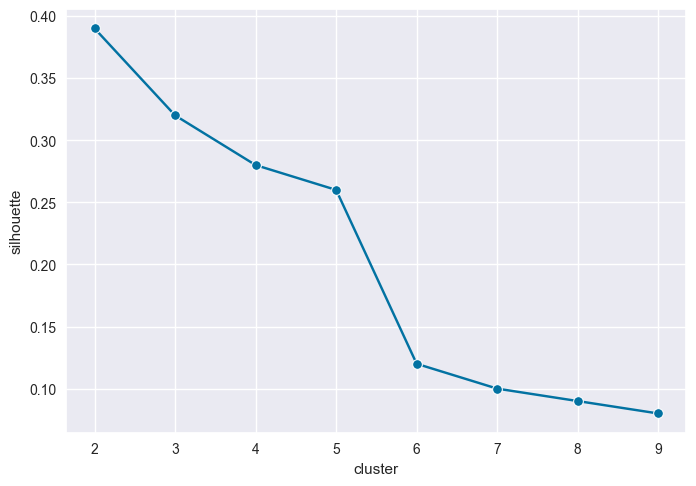

In [ ]:
# напишем функцию, как и при подсчете метода локтя
def get_silhouette(cluster_num, x):
    k_means =  KMeans(n_clusters=cluster_num, random_state=42)#KMeans(n_clusters=cluster_num, random_state=42, init='random')
    k_means.fit(x)
# подсчитаем метрику силуэта, передав данные и то, к каким кластерам относятся объекты
    silhouette = silhouette_score(x, k_means.predict(x))
    return silhouette

# создадим пустой словарь, ключами будут инерция и количество кластеров
silhouette_res1 = {"silhouette": [], "cluster": []}

for cluster_num in range(2, 10):
    silhouette_res1["silhouette"].append(round(get_silhouette(cluster_num, df_scaled), 2))
    silhouette_res1["cluster"].append(cluster_num)
    
# сохраним в датафрейм значение силуэта и количество кластеров
silhouette_df1 = pd.DataFrame(silhouette_res1)

# установим стиль для визуализиции
sns.set_style("darkgrid")
# визуализируем зависимость значения инерции от количества кластеров
sns.lineplot(data=silhouette_df1, x="cluster", y="silhouette", marker= "o")s

In [25]:
cluster_num1 = silhouette_df1.sort_values(by='silhouette', ascending=False).head(1)#.iloc[0,1]
cluster_num1

,silhouette,cluster
0,0.39,2


<Axes: xlabel='cluster', ylabel='silhouette'>

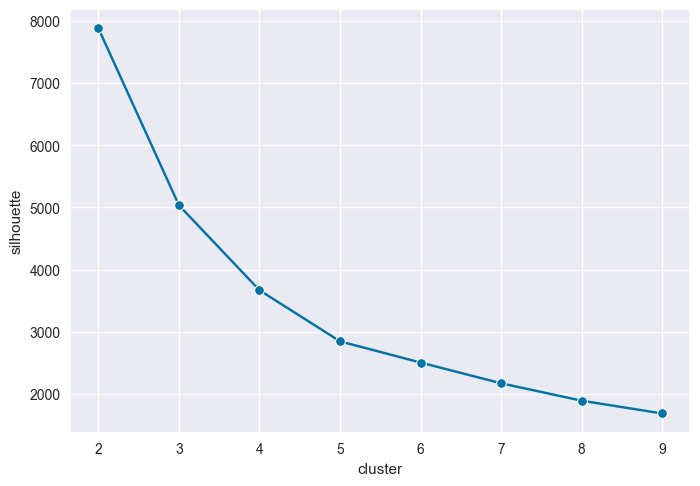

In [26]:
# напишем функцию, как и при подсчете метода локтя
def get_silhouette(cluster_num, x):
    k_means =  KMeans(n_clusters=cluster_num, random_state=42)#KMeans(n_clusters=cluster_num, random_state=42, init='random')
    k_means.fit(x)
# подсчитаем метрику силуэта, передав данные и то, к каким кластерам относятся объекты
    silhouette = calinski_harabasz_score(x, k_means.predict(x))
    return silhouette

# создадим пустой словарь, ключами будут инерция и количество кластеров
silhouette_res2 = {"silhouette": [], "cluster": []}

for cluster_num in range(2, 10):
    silhouette_res2["silhouette"].append(round(get_silhouette(cluster_num, df_scaled), 2))
    silhouette_res2["cluster"].append(cluster_num)
    
# сохраним в датафрейм значение силуэта и количество кластеров
silhouette_df2 = pd.DataFrame(silhouette_res2)

# установим стиль для визуализиции
sns.set_style("darkgrid")
# визуализируем зависимость значения инерции от количества кластеров
sns.lineplot(data=silhouette_df2, x="cluster", y="silhouette", marker= "o")

In [27]:
cluster_num2 = silhouette_df2.sort_values(by='silhouette', ascending=False).head(1)#.iloc[0,1]
cluster_num2

,silhouette,cluster
0,7880.81,2


<Axes: xlabel='cluster', ylabel='silhouette'>

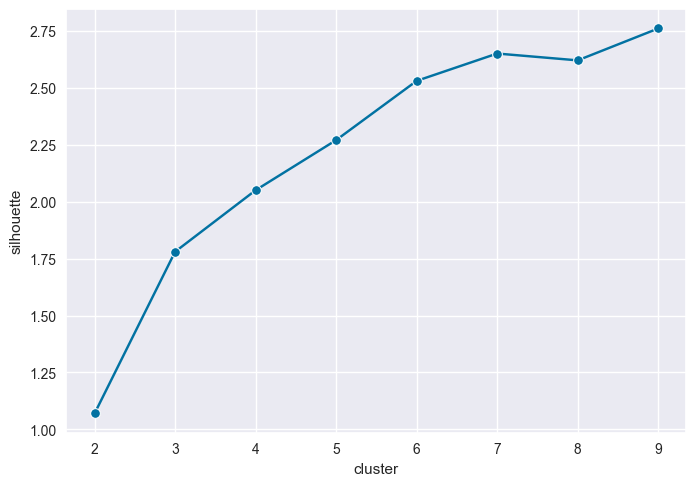

In [28]:
# напишем функцию, как и при подсчете метода локтя
def get_silhouette(cluster_num, x):
    k_means =  KMeans(n_clusters=cluster_num, random_state=42)#KMeans(n_clusters=cluster_num, random_state=42, init='random')
    k_means.fit(x)
# подсчитаем метрику силуэта, передав данные и то, к каким кластерам относятся объекты
    silhouette = davies_bouldin_score(x, k_means.predict(x))
    return silhouette

# создадим пустой словарь, ключами будут инерция и количество кластеров
silhouette_res3 = {"silhouette": [], "cluster": []}

for cluster_num in range(2, 10):
    silhouette_res3["silhouette"].append(round(get_silhouette(cluster_num, df_scaled),2))
    silhouette_res3["cluster"].append(cluster_num)
    
# сохраним в датафрейм значение силуэта и количество кластеров
silhouette_df3 = pd.DataFrame(silhouette_res3)

# установим стиль для визуализиции
sns.set_style("darkgrid")
# визуализируем зависимость значения инерции от количества кластеров
sns.lineplot(data=silhouette_df3, x="cluster", y="silhouette", marker= "o")

In [29]:
cluster_num3 = silhouette_df3.sort_values(by='silhouette', ascending=True).head(1)#iloc[0,1]
cluster_num3

,silhouette,cluster
0,1.07,2


In [39]:
#определяем алгоритм кластеризации
km = KMeans(n_clusters=6, random_state=42, init='random')
#обучаем его на наших данных
y_pred = km.fit_predict(df_scaled)

#вычисляем значение коэффициента силуэта
print('homogeneity_score: ', round(homogeneity_score(y, y_pred), 2))
print('normalized_mutual_info_score: ', round(completeness_score(y, y_pred), 2))
print('adjusted_rand_score: ', round(adjusted_rand_score(y, y_pred), 2))

y_pred = y_pred +1

homogeneity_score:  0.54
normalized_mutual_info_score:  0.58
adjusted_rand_score:  0.42


In [31]:
#создаём таблицу сопряжённости
ct = pd.crosstab(y, y_pred)
#определяем название активностей
ct.index = ['ходьба', 'подъём', 
            'спуск', 'сидение', 'стояние', 'лежание']
ct.columns = list(range(1,7))
ct

,1,2,3,4,5,6
ходьба,741,897,0,0,84,0
подъём,297,1236,2,0,9,0
спуск,882,310,0,0,214,0
сидение,0,1,447,91,0,1238
стояние,0,0,560,0,0,1346
лежание,0,5,329,1556,0,54


In [32]:
y_df = pd.DataFrame(y)
y_df[y_df.shape[1]] = y_pred
y_df = y_df.groupby([y_df.columns[0], y_df.columns[1]])[y_df.columns[1]].count().unstack()
y_df.index = ['ходьба', 'подъём', 
            'спуск', 'сидение', 'стояние', 'лежание']
y_df.columns = list(range(1,7))
y_df

,1,2,3,4,5,6
ходьба,741.0,897.0,NaN,NaN,84.0,NaN
подъём,297.0,1236.0,2.0,NaN,9.0,NaN
спуск,882.0,310.0,NaN,NaN,214.0,NaN
сидение,NaN,1.0,447.0,91.0,NaN,1238.0
стояние,NaN,NaN,560.0,NaN,NaN,1346.0
лежание,NaN,5.0,329.0,1556.0,NaN,54.0


In [40]:
#определяем алгоритм кластеризации
km_2 = KMeans(n_clusters=2, random_state=42, init='random')
#обучаем его на наших данных
y_pred_2 = km_2.fit_predict(df_scaled)

#вычисляем значение коэффициента силуэта
print('homogeneity_score: ', round(homogeneity_score(y, y_pred_2), 2))
print('normalized_mutual_info_score: ', round(completeness_score(y, y_pred_2), 2))
print('adjusted_rand_score: ', round(adjusted_rand_score(y, y_pred_2), 2))

y_pred_2 = y_pred_2 +1

homogeneity_score:  0.38
normalized_mutual_info_score:  0.98
adjusted_rand_score:  0.33


In [36]:
y_df_2 = pd.DataFrame(y)
y_df_2[y_df_2.shape[1]] = y_pred_2
y_df_2 = y_df_2.groupby([y_df_2.columns[0], y_df_2.columns[1]])[y_df_2.columns[1]].count().unstack()
y_df_2.index = ['ходьба', 'подъём', 
            'спуск', 'сидение', 'стояние', 'лежание']
y_df_2.columns = list(range(1,3))
y_df_2

,1,2
ходьба,1722.0,NaN
подъём,1536.0,8.0
спуск,1406.0,NaN
сидение,3.0,1774.0
стояние,NaN,1906.0
лежание,12.0,1932.0


In [ ]:
AC_best_param = AgglomerativeClustering(n_clusters=2)
y_AC = AC_best_param.fit_predict(df_scaled)
y_AC = y_AC + 1
print('normalized_mutual_info_score: ', round(completeness_score(y, y_AC), 2))


normalized_mutual_info_score:  1.0


: 